In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import os
import torch

In [90]:
df_processed = pd.read_csv("../data/processed.csv")

relevant_features = [
    'treatment', 'family_history', 'obs_consequence', 'benefits', 'care_options',

    'leave', 'mental_health_consequence', 'mental_health_interview',

    'Gender_clean_Male', 'Gender_clean_Other'
]

target_col = 'work_interfere'

# WeightedRandomSampler testing

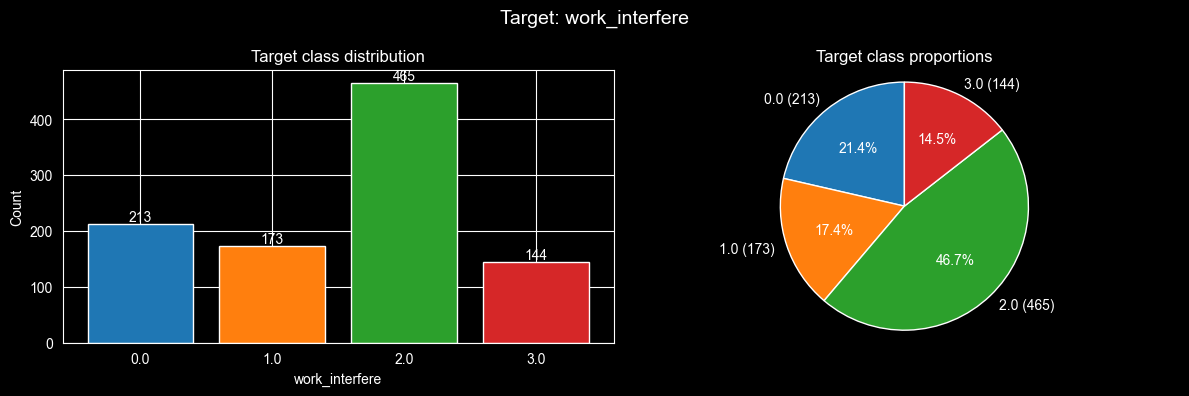

Max/min class ratio: 3.23x
Stratified split + WeightedRandomSampler recommended


In [91]:
target_counts = df_processed[target_col].value_counts().sort_index()
total = len(df_processed)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(target_counts.index.astype(str), target_counts.values, color=sns.color_palette("tab10", len(target_counts)))
ax1.set_title("Target class distribution")
ax1.set_xlabel("work_interfere")
ax1.set_ylabel("Count")

for i, v in enumerate(target_counts.values):
    ax1.text(i, v + total * 0.005, str(v), ha="center", fontsize=10)

ax2.pie(target_counts.values, labels=[f"{i} ({v})" for i, v in zip(target_counts.index, target_counts.values)],
        autopct="%1.1f%%", startangle=90, colors=sns.color_palette("tab10", len(target_counts)))
ax2.set_title("Target class proportions")
ax2.axis("equal")

plt.suptitle("Target: work_interfere", fontsize=14)
plt.tight_layout()
plt.show()

imbalance = target_counts.max() / target_counts.min()
print(f"Max/min class ratio: {imbalance:.2f}x")
print("Stratified split + WeightedRandomSampler recommended" if imbalance > 1.5 else "Classes balanced")


# Train-test split

In [92]:
X = df_processed[relevant_features]
y = df_processed[target_col]

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

print(f"Trainval size: {len(X_trainval)} ({len(X_trainval)/len(X)*100:.1f}%)")
print(f"Test size: {len(X_test)}  ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nClass distribution of trainval: {y_trainval.value_counts().sort_index()}")
print(f"\nClass distribution of test: {y_test.value_counts().sort_index()}")

Trainval size: 796 (80.0%)
Test size: 199  (20.0%)

Class distribution of trainval: work_interfere
0.0    171
1.0    138
2.0    372
3.0    115
Name: count, dtype: int64

Class distribution of test: work_interfere
0.0    42
1.0    35
2.0    93
3.0    29
Name: count, dtype: int64


In [93]:
class_counts = y_trainval.value_counts().sort_index()
class_weights = 1.0 / class_counts
sample_weights = y_trainval.map(class_weights).values

print("Class weights:")
for cls, w in class_weights.items():
    print(f"  class {cls}: {w:.4f}")

Class weights:
  class 0.0: 0.0058
  class 1.0: 0.0072
  class 2.0: 0.0027
  class 3.0: 0.0087


# Scaling

In [94]:
scaler = StandardScaler()

X_trainval_scaled = scaler.fit_transform(X_trainval)
X_test_scaled  = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_trainval_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")

X_train_scaled shape: (796, 10)
X_test_scaled shape:  (199, 10)


# Saving

In [95]:
output_dir = "../data/tensors"
os.makedirs(output_dir, exist_ok=True)

X_trainval_scaled_tensor = torch.tensor(X_trainval_scaled, dtype=torch.float32)
X_test_scaled_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_trainval_tensor = torch.tensor(y_trainval.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)
sample_weights_tensor = torch.tensor(sample_weights, dtype=torch.float32)

torch.save(X_trainval_scaled_tensor, f"{output_dir}/X_trainval.pt")
torch.save(X_test_scaled_tensor, f"{output_dir}/X_test.pt")
torch.save(y_trainval_tensor, f"{output_dir}/y_trainval.pt")
torch.save(y_test_tensor, f"{output_dir}/y_test.pt")
torch.save(sample_weights_tensor, f"{output_dir}/sample_weights.pt")

print("Saved to ../data/tensors/:")

for f in os.listdir(output_dir):
    path = f"{output_dir}/{f}"
    tensor = torch.load(path)
    print(f"  {f:30s} shape={tuple(tensor.shape)} dtype={tensor.dtype}")

Saved to ../data/tensors/:
  X_test.pt                      shape=(199, 10) dtype=torch.float32
  y_test.pt                      shape=(199,) dtype=torch.float32
  y_trainval.pt                  shape=(796,) dtype=torch.float32
  X_trainval.pt                  shape=(796, 10) dtype=torch.float32
  sample_weights.pt              shape=(796,) dtype=torch.float32
